In [1]:
# Purpose:
# Import the libraries and reusable modules needed for Exercise 3

# Source of Code and Justification:
# Exercise 3 builds on the cortical field model from Exercise 2.

# Approach:
# - Add the project root to import modules from src/.
# - Import NumPy and Matplotlib.
# - Import the connectivity functions and the EIUnit class
# - Define the figures directory for saving Exercise 3 plots.

# What to say in Report:
# “For Exercise 3, we reused the cortical field model implemented in Exercise 2.
# We still simulate multiple E-I units coupled through a connectivity matrix W,
# but now we study how localized external stimuli affect network activity.

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

from src.connectivity import generate_sparse_connectivity, generate_unit_connectivity, ring_distance
from src.ei_unit import EIUnit, population_rate_hz

In [2]:
# Purpose:
# Define the network, simulation, and stimulus parameters for Exercise 3.

# Source of Code and Justification:
# Exercise 3 reuses the cortical field model and E/I parameters from Exercises 1 and 2.

# Approach:
# - Reuse the within-unit parameters from Exercise 1 (NE, gamma, p, g, J, tau_delay, LIF, background).
# - Reuse the ring parameters from Exercise 2 (Nunits, sigma, W0).
# - Define the stimulus parameters for Exercise 3.1 (I0, time_onset_ms, stim_exc_unit).

# What to say in Report:
# "Exercise 3 uses the same cortical field model as Exercise 2."

# Number of E-I units for the cortical sheet
Nunits = 10

# Within-unit E/I network parameters from Exercise 1
NE = 1000
gamma = 0.25
NI = int(gamma * NE)
N = NE + NI

p = 0.02
KE = int(p * NE)
KI = int(p * NI)

J = 45.0          # pC
g = 5.0
tau_delay = 2.0  # ms

# LIF neuron parameters
theta = 20.0      # mV
u_reset = -10.0   # mV
R = 1.0           # MOhm
dt = 0.5          # ms
tau_m = 20.0      # ms

# Stochastic background input
n_bg = 25.0
bg_scale = 1.0

# Simulation time
T_ms = 200.0
n_steps = int(round(T_ms / dt))
time_ms = np.arange(n_steps) * dt

# Ring parameters
sigma = 0.2
W0 = 45.0      # pC

#Parameters for ex 3.1
I0 = 30.0     # nA
time_onset_ms = 100.0
stim_exc_unit = 5

Initialized 10 E-I units.
W_unit shape: (20, 20)
I0 = 30.0 nA, sigma = 0.2, W0 = 45.0 pC
Simulation complete.


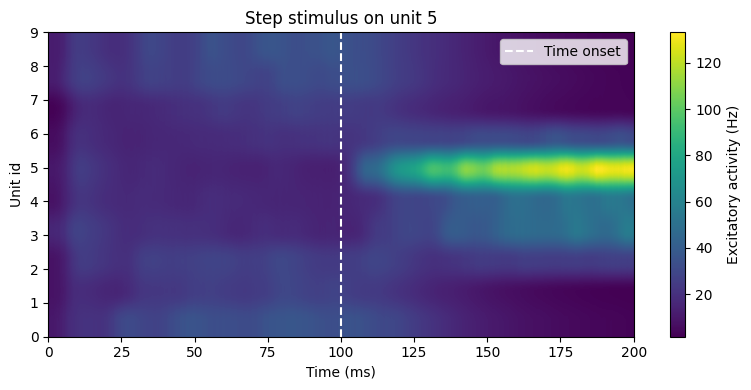

In [3]:
# Purpose:
# Initialize  and simulate the cortical field model for Exercise 3.1 with a step external stimulus, to
# finally plot the 2D excitatory activity map 

# Source of Code and Justification:
# Exercise 3.1 reuses the same coupled field model as Exercise 2.4 : multiple E-I units connected through 
# the population-level matrix W_unit. It also asks for applying a step input to the excitatory population 
# of unit 5 for I_ext,E(t) = I0, for t >= 100 ms, with I0 = 30 nA, T = 200 ms, and W0 = 45 pC. The unit-unit 
# input is still computed as in Exercise 2.4 : I_unit = W_unit @ r_delayed. It finally asks for the same type 
# of plot as Exercise 2.4.

# Approach:
# - Generate W_unit using generate_unit_connectivity with W0 = 45 pC.
# - Create one independent EIUnit per spatial location and store them in a list as before.
# - Build delayed population activity vector [r_E, r_I] with synaptic delay and compute spatial coupling 
#   through W_unit @ r_delayed.
# - Add the step stimulus to I_E_units[stim_exc_unit] when t >= time_onset_ms.
# - Convert population activity from 1/ms to Hz (multiply by 1000) and plot a space-time heatmap.

# What to say in Report:
# "We initialized 10 coupled E-I units through connectivity matrix W on a ring with independent sparse 
# recurrent E/I network. The coupling strength was set to W0 = 45 pC, below the spontaneous bump threshold 
# found in Exercise 2.5. Starting at t = 100 ms, an additional constant external current I0 = 30 nA was applied 
# only to the excitatory population of unit 5. The excitatory activity was visualized as a space-time heatmap. 
# After stimulus onset at t = 100 ms, activity increased around the stimulated unit and propagated to 
# neighboring units."


W_unit, x = generate_unit_connectivity(Nunits, sigma, W0, g, gamma)
seed = 99
units = []

for unit_id in range(Nunits):

    W_recurrent = generate_sparse_connectivity(
        NE=NE,
        NI=NI,
        KE=KE,
        KI=KI,
        J=J,
        g=g,
        seed=seed + unit_id,
    )

    unit = EIUnit(
        W=W_recurrent,
        NE=NE,
        dt=dt,
        tau_m=tau_m,
        R=R,
        theta=theta,
        u_reset=u_reset,
        tau_delay_ms=tau_delay,
        n_bg=n_bg,
        bg_scale=bg_scale,
        rng=np.random.default_rng(seed + 1000 + unit_id),
    )
    units.append(unit)


print(f"Initialized {len(units)} E-I units.")
print("W_unit shape:", W_unit.shape)
print(f"I0 = {I0} nA, sigma = {sigma}, W0 = {W0} pC")


delay_steps = int(round(tau_delay / dt))
alpha_rate = 0.98
# NOTE: Same exponential filter as Ex 2.4 (time constant ≈ 25 ms at dt=0.5 ms).
# The heatmap shows smoothed activity. The stimulus onset at t=100 ms will appear
# slightly delayed and smeared in the plot. The dynamics themselves use r_E_raw.

r_E_raw = np.zeros((n_steps, Nunits), dtype=float)
r_I_raw = np.zeros((n_steps, Nunits), dtype=float)

r_E_plot = np.zeros((n_steps, Nunits), dtype=float)
r_I_plot = np.zeros((n_steps, Nunits), dtype=float)

for k in range(n_steps):

    if k >= delay_steps:
        delayed_activity = np.concatenate([
            r_E_raw[k - delay_steps],
            r_I_raw[k - delay_steps],
        ])

    else:
        delayed_activity = np.zeros(2 * Nunits, dtype=float)

    # Unit-level synaptic input (pC * 1/ms -> nA)
    I_unit = W_unit @ delayed_activity
    I_E_units = I_unit[:Nunits].copy()
    I_I_units = I_unit[Nunits:]

    if time_ms[k] >= time_onset_ms:
        I_E_units[stim_exc_unit] += I0
        
    for alpha, unit in enumerate(units):
        _, _, rE_alpha, rI_alpha = unit.step(
            I_E=I_E_units[alpha],
            I_I=I_I_units[alpha],
        )
        r_E_raw[k, alpha] = rE_alpha
        r_I_raw[k, alpha] = rI_alpha

        if k == 0:
            r_E_plot[k, alpha] = rE_alpha
            r_I_plot[k, alpha] = rI_alpha
        else:
            r_E_plot[k, alpha] = (
                alpha_rate * r_E_plot[k - 1, alpha]
                + (1.0 - alpha_rate) * rE_alpha
            )
            r_I_plot[k, alpha] = (
                alpha_rate * r_I_plot[k - 1, alpha]
                + (1.0 - alpha_rate) * rI_alpha
            )
            
print("Simulation complete.")

r_E_hz = 1000.0 * r_E_plot

plt.figure(figsize=(8, 4))
plt.imshow(
    r_E_hz.T,
    aspect="auto",
    origin="lower",
    extent=[0, T_ms, 0, Nunits - 1],
)

plt.axvline(time_onset_ms, color="white", linestyle="--", linewidth=1.5, label="Time onset")
plt.colorbar(label="Excitatory activity (Hz)")
plt.xlabel("Time (ms)")
plt.ylabel("Unit id")
plt.title(f"Step stimulus on unit {stim_exc_unit}")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex3_1_step_stimulus_unit_5.png", dpi=300)
plt.show()

# 3.1.1 Results plot of a specific unit stimulus 

Before stimulus onset (t<100 ms), all excitatory populations remain low, relatively uniform activity (roughly 10–30 Hz), with small fluctuations from stochastic background input. There is no localized bump and no unit dominates the network. At t=100 ms (step onset on unit 5), activity increases sharply on the stimulated unit : unit 5 reaches very high firing rates (on the order of >100 Hz in the heatmap). This localized high-activity band persists for the rest of the simulation.

Note: the heatmap uses exponential smoothing with a ~25 ms time constant, so the apparent rise after stimulus onset is visually delayed and broadened relative to the true instantaneous firing rate.


# 3.1.2 What happens to the activity of the populations that are not directly stimulated ?

Neighboring units (e.g. units 4 and 6) show a moderate increase in excitatory activity after stimulus onset (intermediate colors, roughly 40–60 Hz). They are not driven directly by $I_{0}$, but receive input through spatial coupling in W : short-range E→E excitation from unit 5 spreads activity to nearby locations on the ring. More distant units (e.g. units 0, 1, 8, 9) remain at low activity, similar to the pre-stimulus baseline. They are not stimulated directly, and the combination of long-range inhibition (distant E populations recruiting local I populations) and weaker long-range excitation prevents a global increase in activity. Non-stimulated populations are not independent of the stimulus, nearby ones are facilitated by lateral excitation, while distant ones stay low because of long-range inhibitory effects mediated by the connectivity structure.

# 3.1.3 Why is it important that $W_{0}$ is below the critical value described in Ex. 2.5 ?

In Exercise 2.5, spontaneous bump formation required approximately $W_{0} ≳ 60$ pC. Here we use $W_{0}=45$ pC, which is below that threshold. That matters for two reasons.
First, no spontaneous attractor : With $W_{0}=45$ pC, the network stays in a low-activity, spatially homogeneous state before the stimulus. The localized high-activity pattern after $t=100$ ms is therefore driven by the external step input, not by a self-sustained bump that would appear even without stimulation.
Second, cleaner interpretation of tuning : Exercises 3.2–3.3 measure responses to controlled stimuli (location, width). If $W_{0}$ were above the critical value, a spontaneous bump could form and compete with or mask the stimulus-evoked pattern, making it hard to tell whether observed activity reflects the stimulus or intrinsic network dynamics.
In short : $W0 < W_{0,critical}$ keeps the network in a sub-threshold regime so that observed spatial patterns are stimulus-evoked, which is essential for studying paradoxical surround suppression in the following exercises.


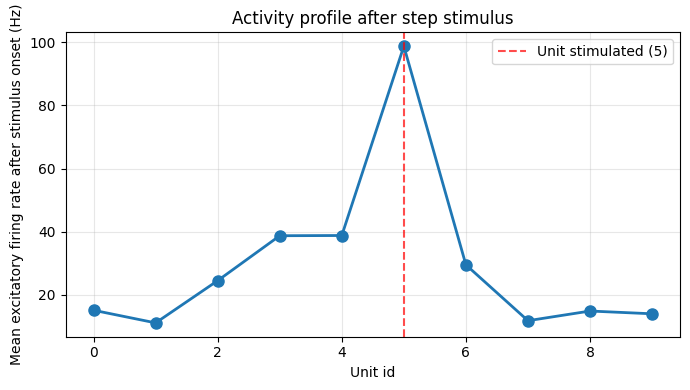

Unit 0 : mean excitatory rate = 15.11 Hz
Unit 1 : mean excitatory rate = 11.11 Hz
Unit 2 : mean excitatory rate = 24.49 Hz
Unit 3 : mean excitatory rate = 38.72 Hz
Unit 4 : mean excitatory rate = 38.78 Hz
Unit 5 : mean excitatory rate = 98.75 Hz
Unit 6 : mean excitatory rate = 29.50 Hz
Unit 7 : mean excitatory rate = 11.80 Hz
Unit 8 : mean excitatory rate = 14.87 Hz
Unit 9 : mean excitatory rate = 13.99 Hz


In [4]:
# Purpose:
# Compute and plot the mean excitatory activity after stimulus onset applied in ex 3.1.

# Source of Code and Justification:
# Exercise 3.2 asks for the mean excitatory activity after stimulus onset as a function of unit 
# location, using the simulation from Exercise 3.1. The stimulus was applied at t = 100 ms to unit 
# stim_exc_unit (5), so we average r_E only over t >= time_onset_ms.

# Approach:
# - Select the post-stimulus time window [time_onset_ms, T_ms].
# - For each unit, compute the mean excitatory activity (in Hz) over that window.
# - Plot mean activity versus unit id.

# What to say in Report:
# "After stimulus onset, we averaged the excitatory population activity of each unit over
# the interval t >= 100 ms. The resulting profile gave a peak at the stimulated unit and
# was decayed with distance along the ring (other units), reflecting short-range excitation 
# and long-range inhibition."


# Time indices after the stimulus onset
after_onset_idx = time_ms >= time_onset_ms

# Mean excitatory activity per unit (Hz) after stimulus onset
mean_rate_E_hz_after = r_E_hz[after_onset_idx, :].mean(axis=0)

unit_ids = np.arange(Nunits)

plt.figure(figsize=(7, 4))
plt.plot(unit_ids, mean_rate_E_hz_after, "o-", linewidth=2, markersize=8)
plt.axvline(stim_exc_unit, color="red", linestyle="--", alpha=0.7,
            label=f"Unit stimulated ({stim_exc_unit})")
plt.xlabel("Unit id")
plt.ylabel("Mean excitatory firing rate after stimulus onset (Hz)")
plt.title("Activity profile after step stimulus")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex3_2_mean_firing_activity_vs_unit.png", dpi=300)
plt.show()

for i in range(Nunits):
    print(f"Unit {i} : mean excitatory rate = {mean_rate_E_hz_after[i]:.2f} Hz")

# 3.2 Tuning curve interpretation 


After averaging excitatory activity for t > 100 ms, the network shows a localized peak at unit 5 (the directly stimulated population). Neighboring units (4 and 6) display intermediate mean activity, while more distant units remain at lower levels. This reflects the connectivity structure : short-range E→E coupling spreads activity locally, whereas long-range E→I coupling suppresses activity in units far from the stimulus.

Therefore, stimulating unit (alpha) and measuring activity at all units is equivalent to fixing the recording unit (e.g. unit 5) and moving the stimulus to different locations on the ring. Because of this radial symmetry, the x-axis can be reinterpreted as unit location (where we measure activity), when the stimulus is fixed at one unit, or as stimulus location (where we apply the input), when the recorded unit is fixed.

In both views, the same profile is obtained : maximum response when the stimulus is centered on the recorded population, with decreasing response as stimulus distance increases. This is the definition of a spatial tuning curve for stimulus position.


Unit investigated : 5
List sigma values : [0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4 ]
Record interval : [50.0, 200.0] ms


sigma_stim sweep: 100%|██████████| 11/11 [00:04<00:00,  2.25it/s]


Done.
sigma_stim = 0.00 -> mean E rate = 133.53 Hz, mean I rate = 83.23 Hz
sigma_stim = 0.04 -> mean E rate = 133.78 Hz, mean I rate = 83.12 Hz
sigma_stim = 0.08 -> mean E rate = 143.21 Hz, mean I rate = 88.85 Hz
sigma_stim = 0.12 -> mean E rate = 149.04 Hz, mean I rate = 92.35 Hz
sigma_stim = 0.16 -> mean E rate = 147.75 Hz, mean I rate = 92.56 Hz
sigma_stim = 0.20 -> mean E rate = 146.47 Hz, mean I rate = 93.20 Hz
sigma_stim = 0.24 -> mean E rate = 144.33 Hz, mean I rate = 92.93 Hz
sigma_stim = 0.28 -> mean E rate = 137.36 Hz, mean I rate = 92.00 Hz
sigma_stim = 0.32 -> mean E rate = 128.55 Hz, mean I rate = 90.40 Hz
sigma_stim = 0.36 -> mean E rate = 120.61 Hz, mean I rate = 88.27 Hz
sigma_stim = 0.40 -> mean E rate = 114.81 Hz, mean I rate = 86.69 Hz


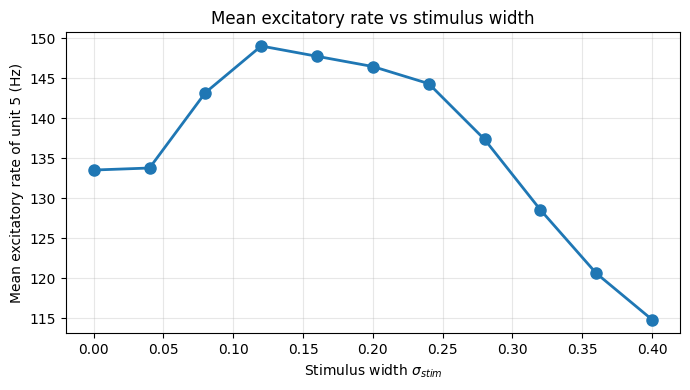

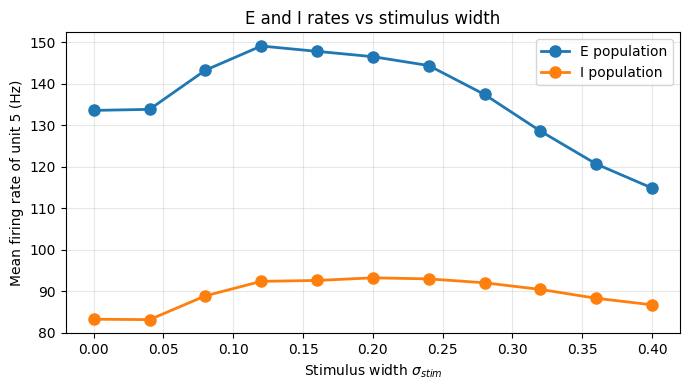

In [5]:
# Purpose:
# Define parameters for the stimulus width, run the cortical field simulation for each stimulus width,
# record the mean excitatory firing rate of the investigated unit, also record the inhibitory rate for
# later interpretation, and finally plot the tuning curve:
# mean excitatory rate vs stimulus width.

# Source of Code and Justification:
# Exercise 3.3 applies a Gaussian external stimulus (Eq. 13) centered on one E-I unit. The stimulus
# width sigma_stim is varied from 0 to 0.4 in steps of 0.04. The firing rate is computed over the last
# 150 ms of a T = 200 ms simulation.
# W0 = 45 pC keeps the network below spontaneous bump formation, as required by Exercise 3.1.
# Eq. (13): I_ext,E_alpha = I0 * exp(-d(x_alpha,x0)^2/(2*sigma_stim^2)),
# with x0 at the investigated unit.
# For sigma_stim = 0, only the investigated unit receives I0.
# To make the comparison across stimulus widths clean, the recurrent sparse connectivity matrices,
# initial membrane potentials, and random seeds are kept fixed across all sigma_stim values.
# Therefore, the main variable changing between simulations is the stimulus width.

# Approach:
# - Fix the unit investigated and its ring position x0.
# - Define the range of sigma_stim values.
# - Define the analysis interval [T_ms - 150, T_ms].
# - Build the unit-unit connectivity matrix once using W0 = 45 pC.
# - Generate recurrent sparse connectivity matrices once, before the sigma_stim loop.
# - Generate initial membrane potentials once, before the sigma_stim loop.
# - For each sigma_stim, build a static Gaussian stimulus profile.
# - Reinitialize fresh EIUnit objects using the same recurrent matrices and same initial potentials.
# - Simulate T = 200 ms with constant external stimulus from t = 0.
# - Average excitatory firing rate of unit_investigated over the last 150 ms and convert to Hz.
# - Also average inhibitory firing rate of unit_investigated over the last 150 ms for Exercise 3.5.
# - Plot mean excitatory rate versus sigma_stim.
# - Plot excitatory and inhibitory rates versus sigma_stim to support the interpretation in Exercise 3.5.

# What to say in Report:
# "We measured how the mean excitatory firing rate of one unit depended on stimulus width. The
# Gaussian stimulus was always centered on that unit, with I0 = 30 nA and W0 = 45 pC. For each stimulus
# width, we ran a 200 ms simulation with a Gaussian input centered on unit 5. The mean excitatory rate
# of unit 5 was averaged over the final 150 ms. To isolate the effect of stimulus width, the recurrent
# sparse connectivity matrices and initial membrane potentials were kept fixed across stimulus widths.
# The tuning curve was non-monotonic: firing rate first increased with stimulus width, then decreased
# beyond a critical sigma, showing surround suppression."


# Unit we measure + center of stimulus
unit_investigated = 5

# Varying sigma_stim: 0 (= single unit) to 0.4 in steps of 0.04.
# We include 0.4 by adding half the step size.
sigma_values = np.arange(0.0, 0.4 + 0.04 / 2, 0.04)

# Record interval: last 150 ms of the 200 ms simulation
record_start_ms = T_ms - 150.0
record_end_ms = T_ms

print(f"Unit investigated : {unit_investigated}")
print(f"List sigma values : {sigma_values}")
print(f"Record interval : [{record_start_ms}, {record_end_ms}] ms")

# Exercise 3 uses W0 = 45 pC, below the spontaneous-bump threshold.
W0 = 45.0

# Unit-unit connectivity is fixed across all stimulus widths.
W_unit, x = generate_unit_connectivity(Nunits, sigma, W0, g, gamma)

# Position of the investigated unit on the ring
x0 = x[unit_investigated]

# Fixed recurrent sparse networks and fixed initial membrane potentials.
# These are generated once and reused for every sigma_stim.
base_seed = seed + 3300

W_recurrent_list = []
u0_list = []

for unit_id in range(Nunits):
    W_recurrent = generate_sparse_connectivity(
        NE=NE,
        NI=NI,
        KE=KE,
        KI=KI,
        J=J,
        g=g,
        seed=base_seed + unit_id,
    )
    W_recurrent_list.append(W_recurrent)

    rng_u0 = np.random.default_rng(base_seed + 1000 + unit_id)
    u0 = rng_u0.uniform(u_reset, theta, size=NE + NI)
    u0_list.append(u0)

mean_rate_unit_investigated = []
mean_rate_I_unit_investigated = []

for sigma_stim in tqdm(sigma_values, desc="sigma_stim sweep"):

    # Build the external stimulus profile.
    # sigma_stim = 0 is treated as a single-unit stimulus.
    if sigma_stim == 0.0:
        I_E_stimulated = np.zeros(Nunits, dtype=float)
        I_E_stimulated[unit_investigated] = I0
    else:
        d = np.array([
            ring_distance(x[alpha], x0)
            for alpha in range(Nunits)
        ])

        I_E_stimulated = I0 * np.exp(
            -(d ** 2) / (2.0 * sigma_stim ** 2)
        )

    # Reinitialize all EI units for this stimulus width.
    # The same recurrent matrix and same starting voltage are reused for each sigma_stim.
    units = []

    for unit_id in range(Nunits):
        unit = EIUnit(
            W=W_recurrent_list[unit_id],
            NE=NE,
            dt=dt,
            tau_m=tau_m,
            R=R,
            theta=theta,
            u_reset=u_reset,
            tau_delay_ms=tau_delay,
            n_bg=n_bg,
            bg_scale=bg_scale,
            rng=np.random.default_rng(base_seed + 2000 + unit_id),
            u0=u0_list[unit_id],
        )
        units.append(unit)

    r_E_raw = np.zeros((n_steps, Nunits), dtype=float)
    r_I_raw = np.zeros((n_steps, Nunits), dtype=float)

    for k in range(n_steps):

        if k >= delay_steps:
            delayed_activity = np.concatenate([
                r_E_raw[k - delay_steps],
                r_I_raw[k - delay_steps],
            ])
        else:
            delayed_activity = np.zeros(2 * Nunits, dtype=float)

        # Unit-unit input from the cortical field model
        I_unit = W_unit @ delayed_activity

        # External stimulus is applied only to the excitatory populations.
        I_E_units = I_unit[:Nunits].copy() + I_E_stimulated
        I_I_units = I_unit[Nunits:].copy()

        for alpha, unit in enumerate(units):
            _, _, rE_alpha, rI_alpha = unit.step(
                I_E=I_E_units[alpha],
                I_I=I_I_units[alpha],
            )

            r_E_raw[k, alpha] = rE_alpha
            r_I_raw[k, alpha] = rI_alpha

    # Mean rate of recorded unit over last 150 ms (Hz)
    mask_time = (time_ms >= record_start_ms) & (time_ms < record_end_ms)

    mean_E_hz = 1000.0 * r_E_raw[mask_time, unit_investigated].mean()
    mean_I_hz = 1000.0 * r_I_raw[mask_time, unit_investigated].mean()

    mean_rate_unit_investigated.append(mean_E_hz)
    mean_rate_I_unit_investigated.append(mean_I_hz)

mean_rate_unit_investigated = np.array(mean_rate_unit_investigated)
mean_rate_I_unit_investigated = np.array(mean_rate_I_unit_investigated)

print("Done.")
for s, rE, rI in zip(
    sigma_values,
    mean_rate_unit_investigated,
    mean_rate_I_unit_investigated,
):
    print(
        f"sigma_stim = {s:.2f} -> "
        f"mean E rate = {rE:.2f} Hz, mean I rate = {rI:.2f} Hz"
    )


# Required Exercise 3.3 plot: excitatory firing rate of investigated unit vs stimulus width
plt.figure(figsize=(7, 4))
plt.plot(
    sigma_values,
    mean_rate_unit_investigated,
    "o-",
    linewidth=2,
    markersize=8,
)
plt.xlabel(r"Stimulus width $\sigma_{stim}$")
plt.ylabel(f"Mean excitatory rate of unit {unit_investigated} (Hz)")
plt.title("Mean excitatory rate vs stimulus width")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex3_3_mean_E_rate_vs_sigma.png", dpi=300)
plt.show()


# Additional diagnostic plot for Exercise 3.5 interpretation
plt.figure(figsize=(7, 4))
plt.plot(
    sigma_values,
    mean_rate_unit_investigated,
    "o-",
    linewidth=2,
    markersize=8,
    label="E population",
)
plt.plot(
    sigma_values,
    mean_rate_I_unit_investigated,
    "o-",
    linewidth=2,
    markersize=8,
    label="I population",
)
plt.xlabel(r"Stimulus width $\sigma_{stim}$")
plt.ylabel(f"Mean firing rate of unit {unit_investigated} (Hz)")
plt.title("E and I rates vs stimulus width")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex3_3_mean_EI_rates_vs_sigma.png", dpi=300)
plt.show()

# 3.3 Stimulus-width tuning curve

I chose unit 5 as the investigated E-I unit. For each stimulus width $\sigma_{stim}$, I applied a constant Gaussian external input centered on this unit. The stimulus amplitude was $I_0 = 30$ nA and the network was simulated for $T = 200$ ms. The mean firing rate was computed over the last 150 ms of the simulation, as required.

To make the comparison across stimulus widths clean, I kept the recurrent sparse connectivity matrices, the initial membrane potentials, and the random seeds fixed across all values of $\sigma_{stim}$. Therefore, the main variable changing between simulations was the stimulus width itself.

The excitatory firing rate of the investigated unit initially increases as the stimulus becomes wider. When the stimulus becomes too wide, the firing rate decreases. 

# 3.4.1 How can the mean firing rate decrease when stimulus width increases ?

When the stimulus is narrow and centered on a unit, only nearby excitatory populations receive strong external input ; they reinforce one another through short-range $W^{E←E}$ coupling ($d ≤ \sigma $), so activity at the center increases. As $\sigma_{stim}$ grows, many more units along the ring are stimulated. Those distant units do not provide strong local excitation to the center, but they recruit inhibitory populations through long-range $W^{I←E}$ coupling (d>σ), increasing inhibition in a broad surround. When that surround inhibition outweighs the benefit of wider direct excitation at the center, the net drive to the recorded excitatory population falls and the mean firing rate decreases—even though the stimulus covers a larger area. This is surround suppression ;a wider stimulus activates inhibition more than useful excitation at the center. 

# 3.4.2 Relation between $\sigma_{stim}$ and connectivity parameters 

The $\sigma_{stim}$ at which the rate begins to fall is set mainly by the spatial scale $\sigma$ in the unit–unit connectivity matrix, which separates short-range excitation from long-range inhibition on the ring. While $\sigma_{stim} ≲ \sigma$, the stimulus stays within the local excitatory neighborhood and the rate typically rises ; when $\sigma_{stim}$ exceeds $\sigma$, the stimulus drives distant units that mainly contribute surround inhibition, so the tuning curve turns down (the peak often lies near $\sigma_{stim} ∼ \sigma – 2\sigma$, e.g. order 0.1–0.2 for $\sigma=0.2$). This transition is modulated by $W_{0}$ (overall coupling strength) and by g and $\gamma$ (inhibitory efficacy via $W^{I←E} = g\gamma W_{0}$) : stronger inhibition or coupling makes the decrease appear at smaller $\sigma_{stim}$. 


# 3.5 Direct cause of the decrease in excitatory firing rate

To determine the direct cause of the decrease in excitatory firing rate for wide stimuli, I compared both the excitatory and inhibitory firing rates of the investigated unit as a function of stimulus width.

The external stimulus was always centered on the investigated unit, so the direct external input received by that unit did not decrease as $\sigma_{stim}$ increased. Therefore, the decrease in excitatory firing rate cannot be explained by a weaker external drive to the recorded unit.

Instead, increasing $\sigma_{stim}$ recruits more surrounding excitatory populations. Through the unit-unit connectivity matrix, nearby populations provide additional short-range excitation, while more distant populations activate inhibitory populations through the long-range $W^{I \leftarrow E}$ pathway. As a result, wider stimuli recruit a stronger inhibitory surround.

This is consistent with the measured firing rates. The excitatory firing rate initially increases as the stimulus becomes wider, but then decreases strongly for large $\sigma_{stim}$. In contrast, the inhibitory firing rate remains relatively elevated and decreases much less strongly than the excitatory rate. Therefore, the direct cause of the suppression is the increased inhibitory influence recruited by the wide stimulus.

This result relates directly to the inhibition-dominated state discussed in Exercise 1. From the mean-field expression,
$$

\langle I^{syn}(t) \rangle
=
J K_E \left(r_E(t) - g\gamma r_I(t)\right),

$$
the network is inhibition-dominated when
$$

g\gamma > 1.

$$
Using the parameters of this project,
$$

g = 5,
\qquad
\gamma = 0.25,
\qquad
g\gamma = 1.25 > 1,

$$
so inhibition dominates excitation in the recurrent dynamics. In this regime, increasing the stimulus width recruits enough inhibitory influence to suppress the central excitatory response, even though the external stimulus itself becomes larger.

An important implication is that an experimentalist measuring only the direct cause of suppression might conclude that the mechanism is simply “more inhibition”. However, the suppression actually emerges from the recurrent E/I circuit architecture of the cortical field model, combining short-range excitation with long-range inhibition. Therefore, the observed suppression is not caused by the external stimulus becoming weaker, but by the recurrent inhibition-dominated network dynamics.